Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df = pd.read_csv("dataset/Chocolate Sales (2).csv")
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


Data Understanding

In [4]:
print("First 5 rows of the DataFrame:")
df.head()

First 5 rows of the DataFrame:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [5]:
print("DataFrame Information:")
df.info()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


Data Preprocessing

In [6]:
# Missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [7]:
# Duplicate values
duplicate_values = df.duplicated().sum()
print("Duplicate Values in the DataFrame:")
print(duplicate_values) 

Duplicate Values in the DataFrame:
0


In [8]:
# Change the data type of 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
print("Data types after converting 'Date' column:")
print(df.dtypes)

Data types after converting 'Date' column:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                   object
Boxes Shipped             int64
dtype: object


In [9]:
# Removed currency symbols and separators from 'Amount' column
df['Amount'] = df['Amount'].str.replace('[$,]', '', regex=True).astype(float)
print("Data types after processing 'Amount' column:")
print(df.dtypes)

Data types after processing 'Amount' column:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object


Exploratory Data Analysis

In [10]:
# Describe the dataset to get a statistical summary of the numerical columns
df.describe()

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


In [11]:
# List all the products and their counts in the dataset
print("Products and their Counts in the Dataset:")
df['Product'].value_counts()

Products and their Counts in the Dataset:


Product
Eclairs                 180
50% Dark Bites          180
Smooth Sliky Salty      177
White Choc              174
Drinking Coco           168
Spicy Special Slims     162
Organic Choco Syrup     156
85% Dark Bars           150
Fruit & Nut Bars        150
After Nines             150
Peanut Butter Cubes     147
99% Dark & Pure         147
Milk Bars               147
Raspberry Choco         144
Almond Choco            144
Orange Choco            141
Mint Chip Choco         135
Manuka Honey Choco      135
Caramel Stuffed Bars    129
70% Dark Bites          126
Baker's Choco Chips     123
Choco Coated Almonds    117
Name: count, dtype: int64

In [12]:
# List all countries and their counts in the dataset
print("Countries and their Counts in the Dataset:")
df['Country'].value_counts()

Countries and their Counts in the Dataset:


Country
Australia      615
India          552
USA            537
UK             534
Canada         525
New Zealand    519
Name: count, dtype: int64

In [13]:
# What products are sold the most and least? What is the total amount of sales for each product?
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each product:")
print(product_sales)

Total sales for each product:
Product
Smooth Sliky Salty      1120201.09
50% Dark Bites          1087659.35
White Choc              1054257.00
Peanut Butter Cubes     1036591.09
Eclairs                  996947.96
99% Dark & Pure          960033.45
85% Dark Bars            955268.24
Organic Choco Syrup      945345.73
Spicy Special Slims      938131.69
Mint Chip Choco          904989.55
Almond Choco             890454.65
Manuka Honey Choco       885208.03
Milk Bars                866273.62
Raspberry Choco          845388.41
After Nines              837215.67
Fruit & Nut Bars         829278.96
Orange Choco             824070.85
Drinking Coco            822245.57
Baker's Choco Chips      799085.67
Choco Coated Almonds     773062.91
Caramel Stuffed Bars     742516.15
70% Dark Bites           677346.22
Name: Amount, dtype: float64


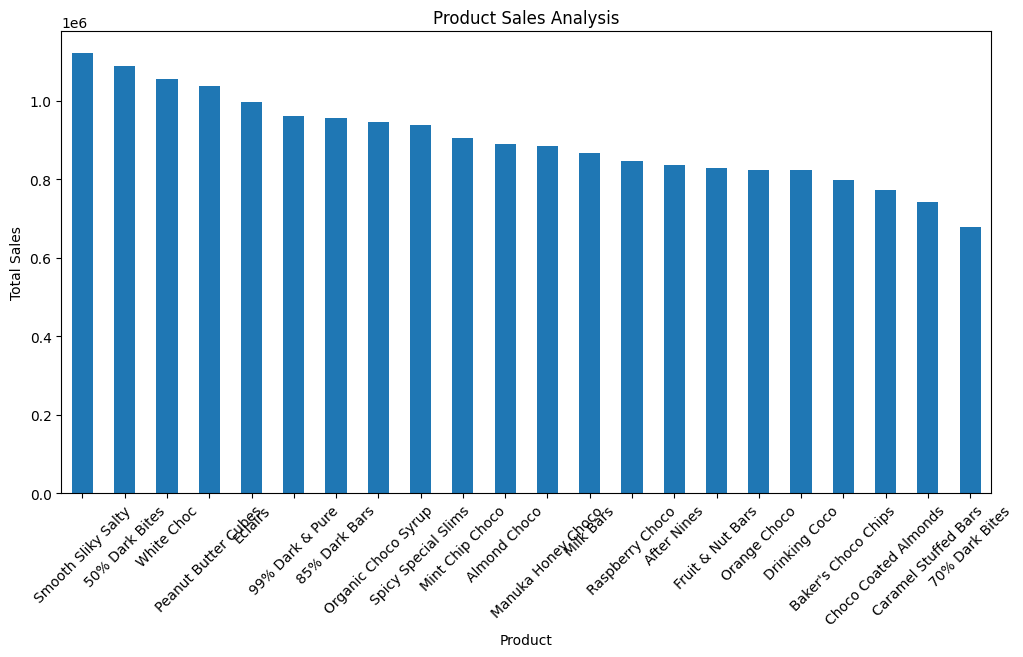

In [14]:
# Visualize the total sales for each product
plt.figure(figsize=(12, 6))
df.groupby('Product')['Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Product Sales Analysis')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Country-wise sales analysis
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each country:")
print(country_sales)

Total sales for each country:
Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64


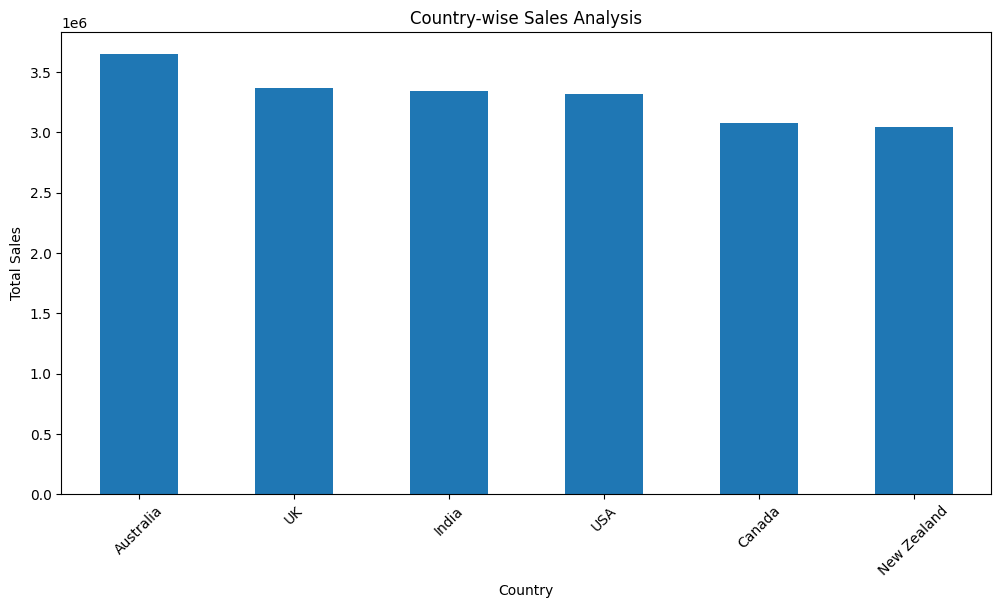

In [16]:
# Visualize the total sales country-wise
plt.figure(figsize=(12, 6))
country_sales.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.title('Country-wise Sales Analysis')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Monthly sales analysis
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Amount'].sum()
print("Total sales for each month:")
print(monthly_sales)

Total sales for each month:
Month
2022-01     896105.00
2022-02     699377.00
2022-03     749483.00
2022-04     674051.00
2022-05     752892.00
2022-06     865144.00
2022-07     803425.00
2022-08     743148.00
2023-01     958985.77
2023-02     749617.46
2023-03     807494.33
2023-04     727743.72
2023-05     811951.78
2023-06     932625.17
2023-07     861856.66
2023-08     793103.07
2024-01    1013621.82
2024-02     783102.44
2024-03     847791.96
2024-04     760132.50
2024-05     850906.79
2024-06     976162.77
2024-07     902250.63
2024-08     830599.99
Freq: M, Name: Amount, dtype: float64


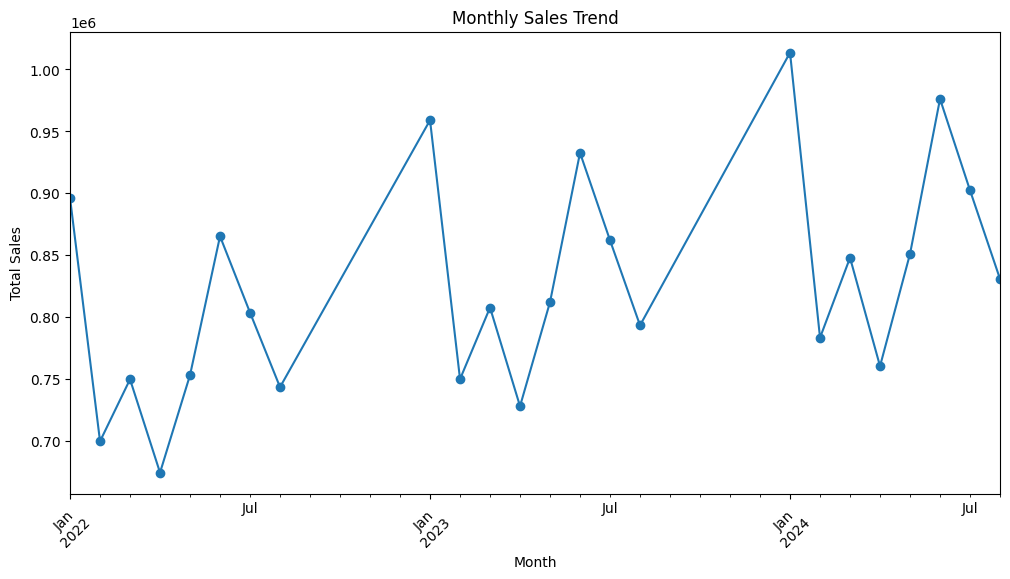

In [18]:
# Visualize monthly sales trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Sales person-wise analysis
salesperson_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each sales person:")
print(salesperson_sales)

Total sales for each sales person:
Sales Person
Ches Bonnell           1022599.96
Oby Sorrel             1017204.12
Madelene Upcott        1010028.72
Kelci Walkden          1002929.10
Brien Boise             997326.48
Van Tuxwell             974425.09
Dennison Crosswaite     931849.57
Beverie Moffet          892421.37
Kaine Padly             849062.76
Marney O'Breen          836427.63
Barr Faughny            830826.91
Roddy Speechley         808359.58
Gunar Cockshoot         762283.43
Gigi Bohling            742296.51
Karlen McCaffrey        713832.64
Jehu Rudeforth          708505.03
Jan Morforth            706585.50
Curtice Advani          691797.92
Rafaelita Blaksland     668865.45
Husein Augar            656149.73
Andria Kimpton          648214.81
Mallorie Waber          642903.33
Camilla Castle          628613.13
Dotty Strutley          608101.17
Wilone O'Kielt          439961.92
Name: Amount, dtype: float64


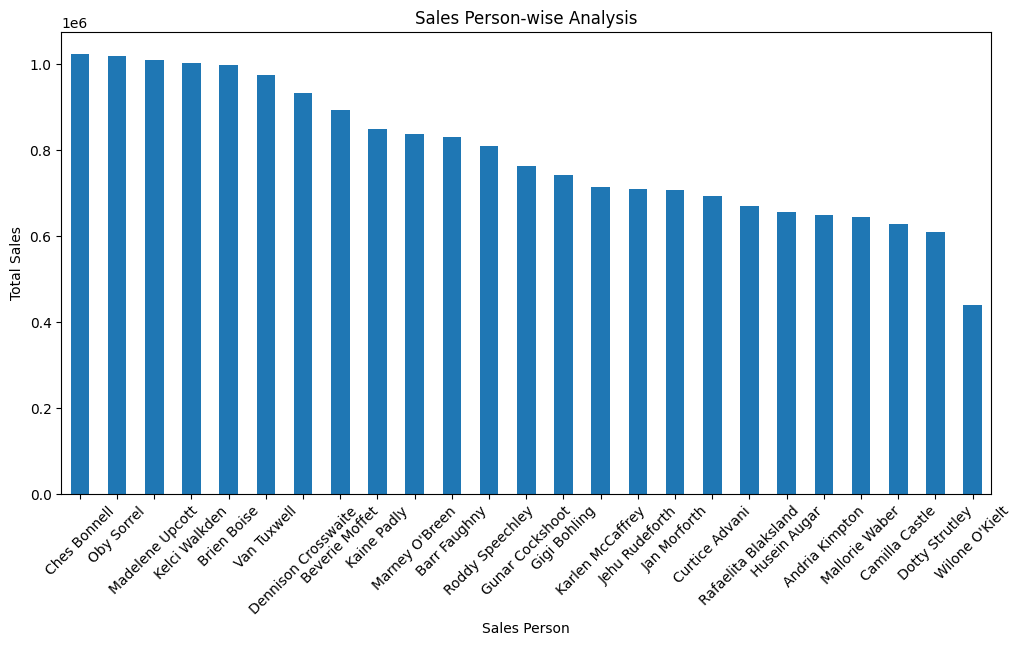

In [22]:
# Visualize sales person-wise analysis
salesperson_sales.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Sales Person')
plt.ylabel('Total Sales')
plt.title('Sales Person-wise Analysis')
plt.xticks(rotation=45)
plt.show()

In [23]:
# Top 5 products with the highest sales
top_5_products = product_sales.head(5) 
print("Top 5 products with the highest sales:")
print(top_5_products)

Top 5 products with the highest sales:
Product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
Name: Amount, dtype: float64
